In [ ]:
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("Drive mounted!")
else:
    print("Drive already mounted, skipping...")

✅ Drive already mounted, skipping...


In [ ]:
!pip install datasets tiktoken -q

from datasets import load_dataset
ds = load_dataset("roneneldan/TinyStories")

In [ ]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm
import shutil

save_dir = '/content/drive/MyDrive/TinyStoriesGPT'
os.makedirs(save_dir, exist_ok=True)

train_bin_drive = f"{save_dir}/train.bin"
val_bin_drive   = f"{save_dir}/validation.bin"

enc = tiktoken.get_encoding("gpt2")

def process(example):
    ids = enc.encode_ordinary(example['text'])
    out = {'ids': ids, 'len': len(ids)}
    return out

if os.path.exists("train.bin"):
    print(".bin files already exist locally, skipping tokenization")


elif os.path.exists(train_bin_drive):
    print("Copying .bin files from Google Drive")
    shutil.copy(train_bin_drive, "train.bin")
    shutil.copy(val_bin_drive,   "validation.bin")
    print("Done, skipping tokenization")


else:
    print("Tokenizing dataset for the first time")
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=2,
    )
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()


    print("Backing up .bin files to Google Drive...")
    shutil.copy("train.bin",      train_bin_drive)
    shutil.copy("validation.bin", val_bin_drive)
    print("Backup complete!")

Copying .bin files from Google Drive
Done, skipping tokenization


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc   = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu   = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer:    int
    n_head:     int
    n_embd:     int
    dropout:    float = 0.0
    bias:       bool  = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                   targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [ ]:
config = GPTConfig(
    vocab_size = 50257,
    block_size = 256,
    n_layer    = 6,
    n_head     = 6,
    n_embd     = 384,
    dropout    = 0.1,
    bias       = True
)

model = GPT(config)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 30,044,544


In [ ]:
import torch
from contextlib import nullcontext

learning_rate             = 3e-4
max_iters                 = 20000
warmup_steps              = 1000
min_lr                    = 1e-5
eval_iters                = 100
eval_interval             = 1000
batch_size                = 32
block_size                = 256
gradient_accumulation_steps = 4

device      = "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

dtype   = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx     = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

print(f"Device: {device} | dtype: {dtype}")

Device: cuda | dtype: bfloat16


In [ ]:
def get_batch(split):
    data = np.memmap('train.bin' if split == 'train' else 'validation.bin',
                     dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x  = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y  = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In [ ]:
@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with ctx:
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [ ]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = learning_rate,
    betas        = (0.9, 0.95),
    weight_decay = 0.1,
    eps          = 1e-9
)


scheduler_warmup = LinearLR(
    optimizer,
    start_factor = 0.1,
    end_factor   = 1.0,
    total_iters  = warmup_steps
)
scheduler_decay = CosineAnnealingLR(
    optimizer,
    T_max   = max_iters - warmup_steps,
    eta_min = min_lr
)
scheduler = SequentialLR(
    optimizer,
    schedulers = [scheduler_warmup, scheduler_decay],
    milestones = [warmup_steps]
)

scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_11640/1874451118.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [ ]:
import os
save_dir = '/content/drive/MyDrive/TinyStoriesGPT'
os.makedirs(save_dir, exist_ok=True)


best_model_path = f"{save_dir}/best_model_params.pt"
checkpoint_path = f"{save_dir}/checkpoint_latest.pt"

best_val_loss        = float('inf')
train_loss_list      = []
validation_loss_list = []

model = model.to(device)


start_epoch = 0
if os.path.exists(checkpoint_path):
    print("Found checkpoint, resuming...")
    ckpt = torch.load(checkpoint_path)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch   = ckpt['epoch']
    best_val_loss = ckpt.get('best_val_loss', float('inf'))
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Starting fresh training...")

for epoch in tqdm(range(start_epoch, max_iters)):


    if epoch % eval_interval == 0 and epoch != 0:
        losses = estimate_loss(model)
        print(f"\nEpoch {epoch} | train loss: {losses['train']:.4f} | val loss: {losses['val']:.4f} | lr: {optimizer.param_groups[0]['lr']:.6f}")
        train_loss_list.append(losses['train'])
        validation_loss_list.append(losses['val'])

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_path)
            print(f" Best model saved to Drive (val loss: {best_val_loss:.4f})")

    # Save checkpoint every 2000 steps
    if epoch % 2000 == 0 and epoch != 0:
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss':        best_val_loss,
        }, checkpoint_path)
        print(f" Checkpoint saved to Drive at epoch {epoch}")

    # Forward pass
    X, y = get_batch("train")
    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    # Optimizer step
    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
print("Training complete! Model saved to Google Drive ")

Found checkpoint, resuming...
✅ Resumed from epoch 18000


  0%|          | 0/2000 [00:00<?, ?it/s]


Epoch 18000 | train loss: 1.8069 | val loss: 1.8114 | lr: 0.000274
✅ Best model saved to Drive (val loss: 1.8114)
💾 Checkpoint saved to Drive at epoch 18000

Epoch 19000 | train loss: 1.7937 | val loss: 1.8058 | lr: 0.000270
✅ Best model saved to Drive (val loss: 1.8058)
Training complete! Model saved to Google Drive ✅


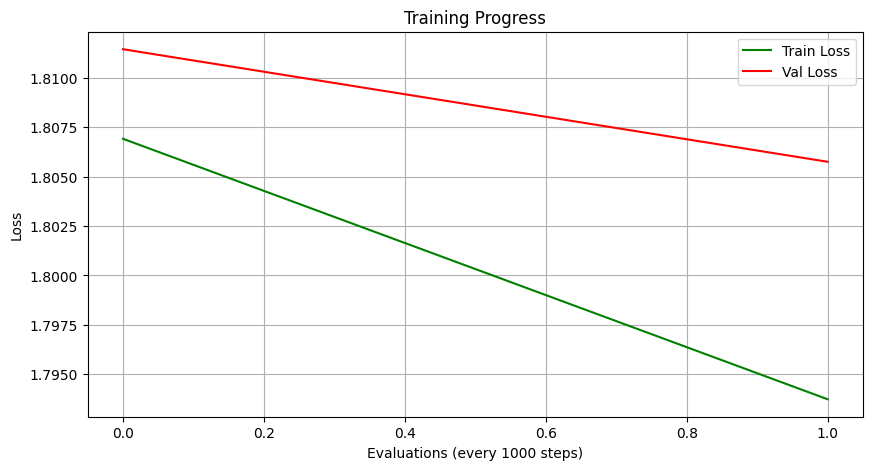

In [ ]:
import matplotlib.pyplot as plt

train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.figure(figsize=(10, 5))
plt.plot(train_loss_list_converted, 'g', label='Train Loss')
plt.plot(validation_loss_list_converted, 'r', label='Val Loss')
plt.xlabel(f"Evaluations (every {eval_interval} steps)")
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/TinyStoriesGPT/best_model_params.pt"))
model.eval()

prompt   = "Once upon a time"
encoded  = enc.encode(prompt)
input_ids = torch.tensor([encoded], dtype=torch.long, device=device)

with torch.no_grad():
    output = model.generate(
        input_ids,
        max_new_tokens = 300,
        temperature    = 0.8,  # lower = more coherent
        top_k          = 40    # restricts to top 40 tokens
    )

story = enc.decode(output[0].tolist())
print("=" * 50)
print(story)
print("=" * 50)

Once upon a time, there was a little bunny named Benny. One day, Benny saw a big tree in the woods. He wanted to climb it, but the tree was too tall for him. 

Benny decided to climb the tree and find a shady spot to rest. He saw a little rabbit hopping around. "Hello little rabbit, what are you doing?" asked Benny. 

The rabbit replied, "I'm climbing the tree, but I'm too small to climb the tree." 

Benny tried to reach the top, but he couldn't reach the top. Suddenly, he slipped and fell. The apple fell down and broke into pieces. Benny cried and cried. 

The next day, Benny saw the little rabbit hopping away from the tree. He was so sad and he wanted to help. Benny remembered what his mom had told him about the day and he promised to be careful in the future.Once upon a time, there was a little girl named Lily. She loved to play outside in the garden with her friends. One day, she saw a lizard crawling on the grass. She realized that it was a lizard.

Lily's mom said, "Lily, it's no